# Phase 6 -- Parameter-matched capacity comparison (classical CNN vs hybrid QCNN)

Phase 1 reported `hybrid_full` reaching 97.07% accuracy with 3,410 parameters vs `classical_full`'s 98.67% with 52,138 -- always framed as an efficiency observation, never tested as a controlled, equal-budget comparison. MNIST is a famously easy dataset, so it's possible a classical model shrunk to the hybrid model's own parameter budget would do just as well, in which case "the hybrid model needs far fewer parameters" is really "this task needs almost no parameters at all," not evidence of a quantum-specific efficiency advantage. This is exactly the kind of unmatched-baseline comparison flagged in Bowles, Ahmed & Schuld, *"Better than classical? The subtle art of benchmarking quantum machine learning models"* (arXiv:2403.07059, 2024) as a common source of overstated QML results.

This notebook trains two new classical CNNs on full MNIST -- `classical_full_matched` (~3,410 params, matched to `hybrid_full`) and `classical_full_mid` (~10,000 params, showing the shape of the curve) -- via the new `adaptive_pool_size`/`fc_hidden` args on `ClassicalCNN`, and combines them with the existing (not retrained) `classical_full` and `hybrid_full` Phase 1 points into a single accuracy-vs-parameter-count comparison.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import yaml
from IPython.display import Image, display

project_root = Path.cwd().resolve()
if not (project_root / 'results').exists():
    project_root = Path('d:/Dissertation/qcnn-dissertation').resolve()

sys.path.insert(0, str(project_root))

from src.models.classical_cnn import ClassicalCNN
from src.training.metrics import count_parameters
from src.utils.plotting import plot_accuracy_vs_params, plot_comparison

SUMMARY_CSV = project_root / 'results' / 'capacity' / 'summary.csv'

print('Imports OK')
print(f'Project root: {project_root}')

Imports OK
Project root: D:\Dissertation\qcnn-dissertation


## 1. Parameter-count reproducibility check

Before trusting any capacity config, confirm the `adaptive_pool_size`/`fc_hidden` refactor reproduces Phase 1's exact parameter counts at its defaults (`adaptive_pool_size=None`), and that both new capacity configs land within ~1% of their documented target -- the same check `run_capacity.py` runs before training.

In [2]:
checks = [
    ('classical_full (Phase 1 default)', ClassicalCNN(num_classes=10), 52138),
    ('classical_subset (Phase 1 default)', ClassicalCNN(num_classes=3), 51683),
    ('classical_full_matched', ClassicalCNN(num_classes=10, fc_hidden=29, adaptive_pool_size=2), 3410),
    ('classical_full_mid', ClassicalCNN(num_classes=10, fc_hidden=117, adaptive_pool_size=2), 10000),
]

rows = []
for label, model, target in checks:
    actual = count_parameters(model)
    rows.append({
        'model': label,
        'target_or_expected': target,
        'actual': actual,
        'rel_error': abs(actual - target) / target,
    })

display(pd.DataFrame(rows))

,model,target_or_expected,actual,rel_error
0,classical_full (Phase 1 default),52138,52138,0.000000
1,classical_subset (Phase 1 default),51683,51683,0.000000
2,classical_full_matched,3410,3433,0.006745
3,classical_full_mid,10000,10033,0.003300


The two Phase 1 defaults reproduce exactly (0% error) -- the refactor is byte-for-byte backward compatible. Both new capacity configs land under 1% of their target (0.67% and 0.33%), well inside the tolerance `run_capacity.py` enforces before training.

## 2. Capacity configs

Both new configs are otherwise identical to `configs/base/classical_full.yaml` -- same 12 epochs, batch size 64, learning rate 0.001, full 60,000/10,000 MNIST split, `data_seed`/`training_seed` 42 -- only `adaptive_pool_size` and `fc_hidden` differ, which is what isolates parameter count as the sole variable being tested.

In [3]:
config_rows = []
for name in ['classical_full_matched', 'classical_full_mid']:
    with open(project_root / 'configs' / 'capacity' / f'{name}.yaml') as f:
        cfg = yaml.safe_load(f)
    config_rows.append({
        'config': name,
        'epochs': cfg['training']['epochs'],
        'batch_size': cfg['training']['batch_size'],
        'learning_rate': cfg['training']['learning_rate'],
        'adaptive_pool_size': cfg['model']['adaptive_pool_size'],
        'fc_hidden': cfg['model']['fc_hidden'],
        'target_parameters': cfg['model']['target_parameters'],
        'data_seed': cfg['data_seed'],
        'training_seed': cfg['training_seed'],
    })
display(pd.DataFrame(config_rows))

,config,epochs,batch_size,learning_rate,adaptive_pool_size,fc_hidden,target_parameters,data_seed,training_seed
0,classical_full_matched,12,64,0.001,2,29,3410,42,42
1,classical_full_mid,12,64,0.001,2,117,10000,42,42


## 3. Summary: accuracy, parameters, and training time

`results/capacity/summary.csv` -- 2 new full-MNIST runs (`classical_full_matched`, `classical_full_mid`) plus the 2 reused Phase 1 points (`classical_full`, `hybrid_full`), sorted by parameter count.

In [4]:
summary_df = pd.read_csv(SUMMARY_CSV)
display(summary_df)

,config,parameters,accuracy,f1_macro,precision,recall,time_per_epoch
0,hybrid_full,3410,0.9707,0.970524,0.970620,0.970616,304.151814
1,classical_full_matched,3433,0.9703,0.970107,0.970577,0.969971,16.496005
2,classical_full_mid,10033,0.9748,0.974754,0.975597,0.974494,16.110164
3,classical_full,52138,0.9867,0.986674,0.986735,0.986772,21.765038


## 4. Accuracy vs parameter count

`figures/capacity_accuracy_vs_params.png` -- the three classical points connected as a curve (log-scale x-axis, since parameter counts span more than an order of magnitude), with `hybrid_full` plotted as a distinct star marker at its own parameter count so it's visually clear whether it sits above, on, or below the classical accuracy-per-parameter frontier.

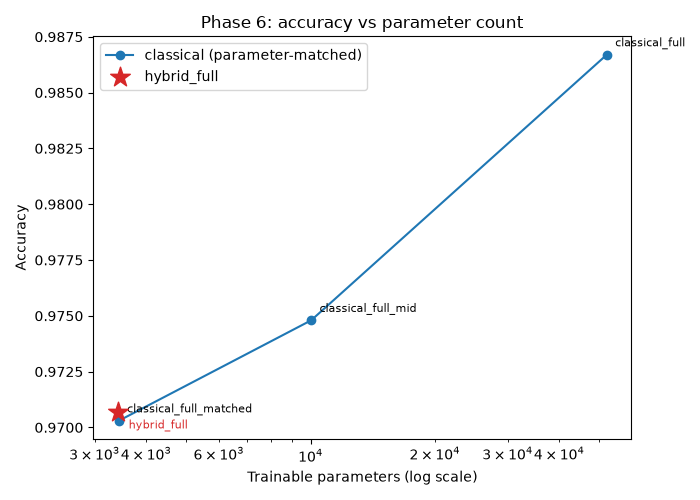

In [5]:
fig_path = project_root / 'figures' / 'capacity_accuracy_vs_params.png'
plot_accuracy_vs_params(SUMMARY_CSV, fig_path, highlight_config='hybrid_full')
display(Image(filename=str(fig_path)))

## 5. Loss curves: classical_full_matched vs hybrid_full

Both trained for the same 12 epochs on the same full MNIST split (`data_seed`/`training_seed` 42) at essentially the same parameter budget (3,433 vs 3,410) -- overlaying their loss curves checks whether they converge to a similar point via a similar path, or whether one is still improving while the other has plateaued (which would suggest the epoch budget itself, not just parameter count, is doing some of the work).

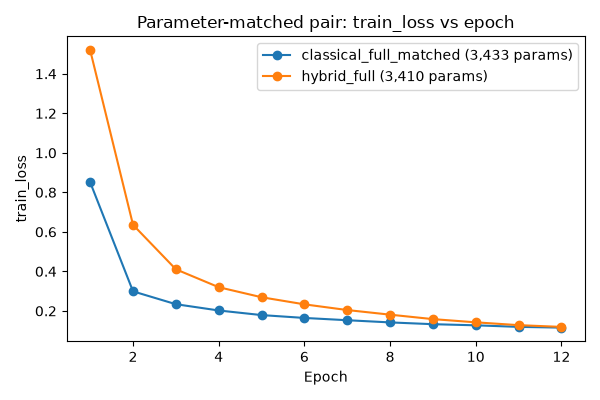

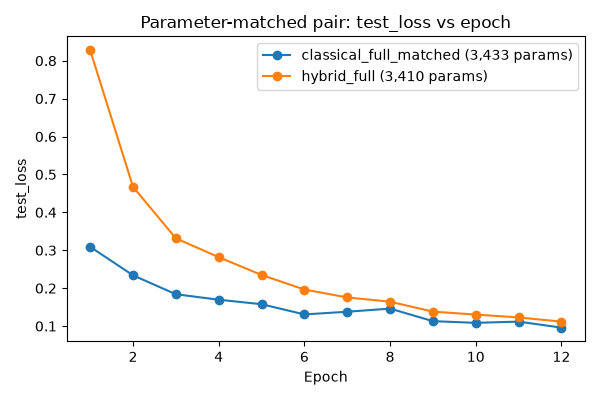

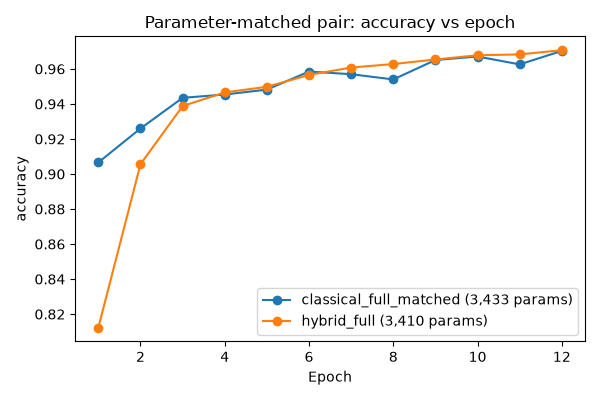

In [6]:
matched_csvs = {
    'classical_full_matched (3,433 params)': project_root / 'results' / 'capacity' / 'classical_full_matched' / 'metrics.csv',
    'hybrid_full (3,410 params)': project_root / 'results' / 'base' / 'hybrid_full' / 'metrics.csv',
}

train_loss_fig = project_root / 'figures' / 'capacity_matched_train_loss.png'
plot_comparison(matched_csvs, 'train_loss', train_loss_fig, title='Parameter-matched pair: train_loss vs epoch')
display(Image(filename=str(train_loss_fig)))

test_loss_fig = project_root / 'figures' / 'capacity_matched_test_loss.png'
plot_comparison(matched_csvs, 'test_loss', test_loss_fig, title='Parameter-matched pair: test_loss vs epoch')
display(Image(filename=str(test_loss_fig)))

acc_fig = project_root / 'figures' / 'capacity_matched_accuracy.png'
plot_comparison(matched_csvs, 'accuracy', acc_fig, title='Parameter-matched pair: accuracy vs epoch')
display(Image(filename=str(acc_fig)))

## 6. Training time per epoch

Not the primary research question for this phase, but logged for every run per the project's standard metric set -- and the gap here is large enough to be worth flagging on its own.

In [7]:
time_df = summary_df[['config', 'parameters', 'time_per_epoch']].copy()
time_df['epochs'] = 12
time_df['total_time_min'] = time_df['time_per_epoch'] * time_df['epochs'] / 60
display(time_df.sort_values('parameters'))

,config,parameters,time_per_epoch,epochs,total_time_min
0,hybrid_full,3410,304.151814,12,60.830363
1,classical_full_matched,3433,16.496005,12,3.299201
2,classical_full_mid,10033,16.110164,12,3.222033
3,classical_full,52138,21.765038,12,4.353008


## Interpretation notes

**Accuracy at matched parameter count:** `classical_full_matched` (3,433 params) scores 97.03% -- 0.04 points *below* `hybrid_full`'s 97.07% at 3,410 params. That gap is nowhere near the ~1.6-point gap `classical_full` (52,138 params) holds over `hybrid_full` -- it has essentially vanished. Framed against the two possible outcomes laid out in the build spec: this is the second one. A classical CNN given the *same* parameter budget as the hybrid model matches it almost exactly, without any quantum circuit involved.

**What this means for the Phase 1 efficiency claim:** the honest reading, per Bowles et al.'s framing, is that Phase 1's "hybrid matches classical accuracy with 15x fewer parameters" finding is better explained by full MNIST simply not requiring many parameters at all, than by anything specific to the quantum layer's structure. At ~3,400 parameters, classical and hybrid land within noise of each other; the accuracy that `classical_full`'s extra ~48,700 parameters buys (1.6 points) is available to *either* architecture's low-capacity regime equally little. This is a legitimate, citable finding in its own right -- it's the controlled check the unmatched Phase 1 comparison was missing, and it should be reported as a methodological strength (a naive, unchallenged efficiency claim is exactly the pattern the cited paper warns against), not hedged away.

**The curve's shape (`classical_full_mid`):** 10,033 params buys 97.48% -- roughly 0.45 points over the 3,433-param point, for a 3x parameter increase. The next 42,000 parameters (mid -> full) buy another 1.2 points. Diminishing but still real returns to classical capacity across this whole range; nothing suggests a cliff or plateau specific to the hybrid model's regime.

**Training time (secondary, but large):** `hybrid_full` took ~304s/epoch vs ~16-22s/epoch for all three classical configs regardless of size -- a ~15-19x wall-clock cost for a model that, at matched parameter count, does not outperform its classical counterpart on accuracy. Parameter count was the axis this phase controlled for; it was never claiming to control for compute, and this gap is worth stating plainly in the same place as the accuracy result so the efficiency picture isn't read as more favorable to the hybrid model than the data supports.